In [1]:
!pip install pybedtools
!apt-get update
!apt-get install -y bedtools
!pip install Bio


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 14.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.0/24.0 MB 101.2 MB/s eta 0:00:00
  Created wheel for pybedtools: filename=pybedtools-0.12.0-cp312-cp312-linux_x86_64.whl size=14340834 sha256=1f2cd184b4caa807368ead30e47c05c1ec73280d959062a8156b4ee3f3eeea81
  Stored in directory: /root/.cache/pip/wheels/ac/38/f2/960d79e44a92afc0d34a4727c856ce0149ac23c3dcda174356
Successfully built pybedtools
Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat

In [2]:
!wget https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM607nnn/GSM607482/suppl/GSM607482%5FwgEncodeYaleChIPseqSignalK562bZnf274.bed.gz
!gzip -d /content/GSM607482_wgEncodeYaleChIPseqSignalK562bZnf274.bed.gz
!wget http://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz
!gunzip hg38.fa.gz

--2025-11-10 17:11:52--  https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM607nnn/GSM607482/suppl/GSM607482%5FwgEncodeYaleChIPseqSignalK562bZnf274.bed.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.13, 130.14.250.7, 130.14.250.10, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 202884440 (193M) [application/x-gzip]
Saving to: ‘GSM607482_wgEncodeYaleChIPseqSignalK562bZnf274.bed.gz’

GSM607482_wgEncodeY 100%[===================>] 193.49M  40.5MB/s    in 5.1s    

2025-11-10 17:11:58 (37.6 MB/s) - ‘GSM607482_wgEncodeYaleChIPseqSignalK562bZnf274.bed.gz’ saved [202884440/202884440]

--2025-11-10 17:12:09--  http://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz
Resolving hgdownload.soe.ucsc.edu (hgdownload.soe.ucsc.edu)... 128.114.119.163
Connecting to hgdownload.soe.ucsc.edu (hgdownload.soe.ucsc.edu)|128.114.119.163|:80... connected.
HTTP request sent, awaiting

In [3]:
import subprocess
import random
from pybedtools import BedTool
from Bio import SeqIO
import os

In [4]:
!mkdir data

In [5]:
class DNAparser():
  def __init__(self, bed_file, genome_file, seq_num) -> None:
    self.bed = bed_file
    self.genome = genome_file
    self.bed_lst = None
    self.n = seq_num

  def bed_file_reader(self):
    chrom = "chr21"
    bed_chr21 = "data/chr21.bed"
    cmd = f"awk '$1==\"{chrom}\"' {self.bed} > {bed_chr21}"
    subprocess.run(cmd, shell=True)
    self.bed_lst = list(BedTool("data/chr21.bed"))

    return self.bed_lst

  def random_intervals(self):
    random.seed(42)
    bed_lst = self.bed_file_reader()
    random_intervals = random.sample(bed_lst, self.n)
    return random_intervals

  def get_equal_len_for_bed(self):
    res_intervals = []
    intervals = self.random_intervals()

    for data in intervals:
      start = int(data.start)
      end = int(data.end)

      middle = (start + end) // 2
      new_start = max(0, middle - 100)
      new_end = middle + 100

      data.start = new_start
      data.end = new_end

      res_intervals.append(data)

    return res_intervals

  def from_bed_to_fasta(self, intervals, bed_file_name, output_fasta):
    temp_bed = BedTool(intervals).saveas("data/" + bed_file_name)
    cmd = [
        "bedtools", "getfasta",
        "-fi", self.genome,
        "-bed", "data/" + bed_file_name,
        "-fo", "data/" + output_fasta,
        "-s"  # учитывать strand
    ]

    # Получили FASTA-файл с целевым классом
    result = subprocess.run(cmd, capture_output=True, text=True)

  def from_fasta_to_genome(self):
    genome_intervals = "data/GRCh38.genome"
    keep = {"chr21"}

    with open(genome_intervals, "w") as file:
      for record in SeqIO.parse(self.genome, 'fasta'):
        if record.id not in keep:
                continue

        chrom = record.id
        length = len(record.seq)
        file.write(f"{chrom}\t{length}\n")

    return genome_intervals

  def get_fasta_seqs(self):
    window_size = 200
    genome_intervals = self.from_fasta_to_genome()

    windows = (
        BedTool()
        .window_maker(g=genome_intervals, w=window_size)
        .saveas("data/windows.bed")
    )
    exclude = BedTool(self.bed_lst).saveas("data/exclude.bed")

    windows_no_intersect = (
        windows.intersect(exclude, v=True)
        .saveas("data/windows_no_intersect.bed")
    )

    return "data/windows_no_intersect.bed"

  def fasta_parser(self, output_fasta):
    with open("data/" + output_fasta, "r") as file:
      sequences = []
      cur_sequences = ""
      for i_line in file:
        if i_line.startswith(">"):
          if cur_sequences:
            sequences.append(cur_sequences)
          cur_sequences = ""
        else:
          cur_sequences += i_line.strip()
      sequences.append(cur_sequences)

      return sequences

  def files_to_remove(self):
    files = [
        "/content/data/exclude.bed",
        "/content/data/others_200bp_target.bed",
        "/content/data/random_200bp_target.bed",
        "/content/data/windows.bed",
        "/content/data/windows_no_intersect.bed"
    ]
    for file in files:
      os.remove(file)

  def get_target_class(self):
    output_fasta = "target_class_sequences.fasta"
    bed_file_name = "random_200bp_target.bed"
    intervals = self.get_equal_len_for_bed()
    self.from_bed_to_fasta(intervals, bed_file_name, output_fasta)

    res = self.fasta_parser(output_fasta)
    return res

  def get_others_class(self):
    random.seed(42)
    no_intersects = list(BedTool(self.get_fasta_seqs()))
    intervals = random.sample(no_intersects, self.n)
    output_fasta = "others_class_sequences.fasta"
    bed_file_name = "others_200bp_target.bed"
    self.from_bed_to_fasta(intervals, bed_file_name, output_fasta)

    res = self.fasta_parser(output_fasta)
    self.files_to_remove()
    return res


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_curve, auc, roc_auc_score, precision_recall_curve, average_precision_score
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import matplotlib.pyplot as plt

In [7]:
class DNAData(Dataset):
  def __init__(self, sequences, labels) -> None:
    super().__init__()
    self.sequences = sequences
    self.labels = labels

    self.encoder = {"A": 0, "G": 1, "C": 2, "T": 3}
    self.len = len(sequences[0])

    self.encoded_sequences = [self._encode_sequence(seq) for seq in self.sequences]

  def _encode_sequence(self, seq):
    encoded = torch.zeros(self.len, 4)

    for ind, nucl in enumerate(seq):
      if nucl in self.encoder:
        encoded[ind, self.encoder[nucl]] = 1.0

    return encoded

  def __len__(self):
    return len(self.sequences)

  def __getitem__(self, ind):
    sequence = self.encoded_sequences[ind]
    label = torch.tensor(self.labels[ind], dtype=torch.long)
    return sequence, label


In [8]:
class DNA_CNN(nn.Module):
  def __init__(self, input_channels=4, num_classes=2) -> None:
    super().__init__()

    self.conv_layers = nn.Sequential(
        #first Convolutional layer
        nn.Conv1d(input_channels, 64, kernel_size=10, padding=5),
        nn.ReLU(),
        nn.BatchNorm1d(64),
        nn.MaxPool1d(2),
        nn.Dropout(0.3),

        #second Convolutional layer
        nn.Conv1d(64, out_channels=128, kernel_size=6, padding=3),
        nn.ReLU(),
        nn.BatchNorm1d(128),
        nn.MaxPool1d(2),
        nn.Dropout(0.3),

        #third Convolutional layer
        nn.Conv1d(128, out_channels=256, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.BatchNorm1d(256),
        nn.MaxPool1d(2),
        nn.Dropout(0.3),
    )

    self.classifier = nn.Sequential(
        nn.AdaptiveAvgPool1d(1),
        nn.Flatten(),
        nn.Linear(256, 128),
        nn.GELU(),
        nn.Linear(128, 64),
        nn.GELU(),
        nn.Linear(64, 32),
        nn.GELU(),
        nn.Linear(32, num_classes)
    )

  def forward(self, x):
    x = x.permute(0, 2, 1)

    x = self.conv_layers(x)
    x = self.classifier(x)

    return x


In [9]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epoch=50, device="gpu"):
  train_losses, val_losses = [], []
  train_accs, val_accs = [], []

  for epoch in range(num_epoch):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for batch_ind, (data, target) in enumerate(train_loader):
      data, target = data.to(device), target.to(device)

      optimizer.zero_grad()
      predictions = model(data)
      loss = criterion(predictions, target)
      loss.backward()
      optimizer.step()

      running_loss += loss.item()
      _, predicted = predictions.max(1)
      total += target.size(0)
      correct += predicted.eq(target).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total * 100.

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validation phase
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
      for data, targets in val_loader:
          # Move data to the same device as model
          data, targets = data.to(device), targets.to(device)

          outputs = model(data)
          loss = criterion(outputs, targets)

          val_loss += loss.item()
          _, predicted = outputs.max(1)
          total += targets.size(0)
          correct += predicted.eq(targets).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = 100. * correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # if (epoch + 1) % 10 == 0:
    print(f'Epoch [{epoch+1}/{num_epoch}]')
    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
    print('-' * 50)

  return train_losses, val_losses, train_accs, val_accs

In [10]:

bed_file = "/content/GSM607482_wgEncodeYaleChIPseqSignalK562bZnf274.bed"
genome_file_fasta = "/content/hg38.fa"
seq_num = 10000
parser = DNAparser(bed_file, genome_file_fasta, seq_num)
target_seqs = parser.get_target_class()
others_seqs = parser.get_others_class()


In [11]:
len(target_seqs)
others_seqs = others_seqs[:len(target_seqs)]
len(others_seqs)

9922

Using device: cuda
Training samples: 12700
Validation samples: 3175
Test samples: 3969
Starting training...
Epoch [1/15]
Train Loss: 0.6461, Train Acc: 66.39%
Val Loss: 0.7173, Val Acc: 42.46%
--------------------------------------------------
Epoch [2/15]
Train Loss: 0.6059, Train Acc: 70.56%
Val Loss: 0.7747, Val Acc: 50.02%
--------------------------------------------------
Epoch [3/15]
Train Loss: 0.5994, Train Acc: 71.65%
Val Loss: 0.7953, Val Acc: 44.88%
--------------------------------------------------
Epoch [4/15]
Train Loss: 0.5993, Train Acc: 71.41%
Val Loss: 0.6208, Val Acc: 69.70%
--------------------------------------------------
Epoch [5/15]
Train Loss: 0.5965, Train Acc: 71.57%
Val Loss: 0.6433, Val Acc: 61.39%
--------------------------------------------------
Epoch [6/15]
Train Loss: 0.5941, Train Acc: 71.76%
Val Loss: 0.6145, Val Acc: 69.32%
--------------------------------------------------
Epoch [7/15]
Train Loss: 0.5928, Train Acc: 71.76%
Val Loss: 0.6010, Val Acc

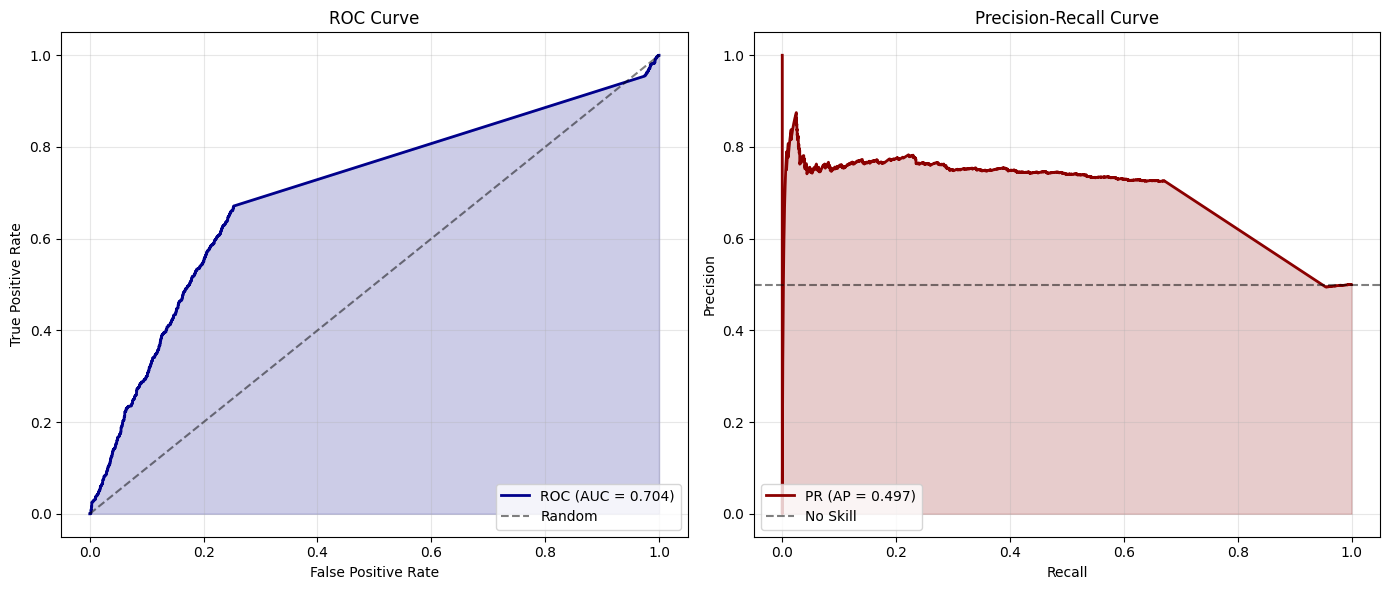

In [13]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

sequences = target_seqs + others_seqs
labels = [1 if i <= len(sequences) // 2 else 0 for i in range(1, len(sequences) + 1)]

#split_data
X_train, X_test, y_train, y_test = train_test_split(sequences, labels, test_size=0.2, shuffle=True, stratify=labels, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

# Create datasets
train_dataset = DNAData(X_train, y_train)
val_dataset = DNAData(X_val, y_val)
test_dataset = DNAData(X_test, y_test)

# Create dataloader
batch_size = 1024
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Initialize model
model = DNA_CNN(input_channels=4, num_classes=2)
model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=5e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

# Train model
print("Starting training...")
train_losses, val_losses, train_accs, val_accs = train_model(
    model, train_loader, val_loader, criterion, optimizer, num_epoch=15, device=device
)

# Evaluate on test set
model.eval()
test_correct = 0
test_total = 0
all_probs = []  # вероятности для ROC-AUC
all_preds = []
all_targets = []

with torch.no_grad():
    for data, targets in test_loader:
        # Move data to the same device as model
        data, targets = data.to(device), targets.to(device)

        outputs = model(data)
        _, predicted = outputs.max(1)
        test_total += targets.size(0)

        # Вероятности положительного класса для ROC-AUC
        probs = nn.functional.softmax(outputs, dim=1)[:, 1]
        all_probs.extend(probs.cpu().numpy())

        test_correct += predicted.eq(targets).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

test_acc = 100. * test_correct / test_total
print(f'Test Accuracy: {test_acc:.2f}%')

# Classification report
print("\nClassification Report:")
print(classification_report(all_targets, all_preds))

# --- ROC кривая ---
fpr, tpr, thresholds = roc_curve(all_targets, all_probs)
roc_auc = auc(fpr, tpr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
ax1.fill_between(fpr, tpr, alpha=0.2, color='darkblue')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)

# --- Precision-Recall кривая ---

precision, recall, thresholds = precision_recall_curve(all_targets, all_probs)
ap = average_precision_score(all_targets, all_preds)

ax2.plot(recall, precision, color='darkred', lw=2, label=f'PR (AP = {ap:.3f})')
no_skill = sum(all_targets) / len(all_targets)
ax2.axhline(y=no_skill, color='k', linestyle='--', alpha=0.5, label='No Skill')
ax2.fill_between(recall, precision, alpha=0.2, color='darkred')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc='lower left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()
